# Bài toán phân loại nhị phân

Theo dõi chỉ số tình trạng kỹ thuật tổng hợp của máy qua 300 chu kỳ giám sát, trong đó
có 7 chu kỳ thực sự bất thường **và đã được gán nhãn** sau khi kiểm tra thực tế.
Vì chưa tới 3 % số chu kỳ mang nhãn bất thường nên không dùng độ chính xác mà
đánh giá bằng precision, recall và F1.

## Bảng dữ liệu

So chu ky: 300 | So chu ky bat thuong: 7 | Ty le: 2.3 %


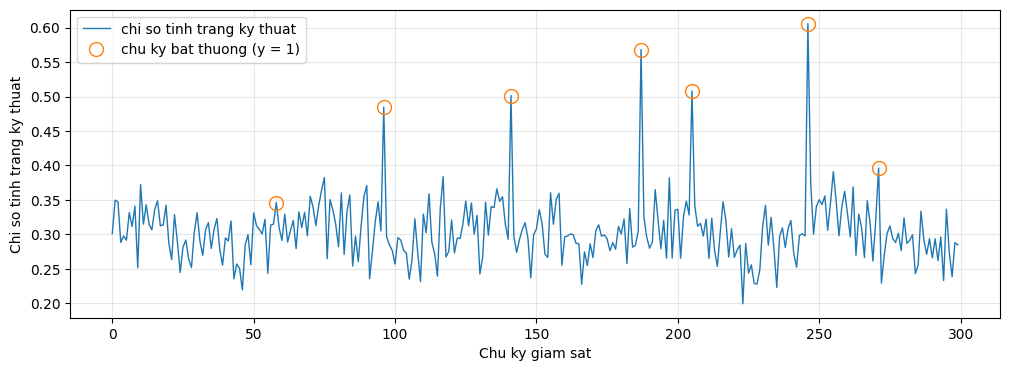

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(11)
T = 300
t = np.arange(T)
value = 0.30 + 0.02*np.sin(2*np.pi*t/60) + rng.normal(0, 0.035, T)
position = np.array([58, 96, 141, 187, 205, 246, 271])   # cac chu ky bat thuong
value[position] += rng.uniform(0.11, 0.30, len(position))
y = np.zeros(T, int); y[position] = 1         # 1 = bat thuong
X = value.reshape(-1, 1)                      # moi hang mot chu ky

print("So chu ky:", T, "| So chu ky bat thuong:", y.sum(), "| Ty le: %.1f %%" % (100*y.mean()))

plt.figure(figsize=(12, 4))
plt.plot(t, value, lw=1, label='chi so tinh trang ky thuat')
plt.plot(t[y == 1], value[y == 1], 'o', mfc='none', ms=10, label='chu ky bat thuong (y = 1)')
plt.xlabel('Chu ky giam sat'); plt.ylabel('Chi so tinh trang ky thuat')
plt.grid(True, alpha=.3); plt.legend(); plt.show()

## Hồi quy logistic không bù

In [2]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

# Cau hinh 1: khong bu mat can bang lop
name_1 = 'Logistic Regression (No Weight)'
model_1 = make_pipeline(StandardScaler(), LogisticRegression(class_weight=None))
predict_1 = cross_val_predict(model_1, X, y, cv=cv)
p_1, r_1, f1_1, _ = precision_recall_fscore_support(y, predict_1, average='binary')
cm_1 = confusion_matrix(y, predict_1)

print(f"Cau hinh 1: {name_1}")
print(f"Precision: {p_1:.2f}", f"Recall: {r_1:.2f}", f"F1: {f1_1:.2f}")
print(f"Confusion Matrix: TP = {cm_1[1, 1]}; TN = {cm_1[0, 0]}; "
      f"FP = {cm_1[0, 1]}; FN = {cm_1[1, 0]}")

Cau hinh 1: Logistic Regression (No Weight)
Precision: 1.00 Recall: 0.71 F1: 0.83
Confusion Matrix: TP = 5; TN = 293; FP = 0; FN = 2


## Hồi quy logistic có bù

In [3]:
# Cau hinh 2: bu mat can bang lop bang class_weight='balanced'
name_2 = 'Logistic Regression (Balanced Weight)'
model_2 = make_pipeline(StandardScaler(),
                        LogisticRegression(class_weight='balanced'))
predict_2 = cross_val_predict(model_2, X, y, cv=cv)
p_2, r_2, f1_2, _ = precision_recall_fscore_support(y, predict_2, average='binary')
cm_2 = confusion_matrix(y, predict_2)

print(f"Cau hinh 2: {name_2}")
print(f"Precision: {p_2:.2f}", f"Recall: {r_2:.2f}", f"F1: {f1_2:.2f}")
print(f"Confusion Matrix: TP = {cm_2[1, 1]}; TN = {cm_2[0, 0]}; "
      f"FP = {cm_2[0, 1]}; FN = {cm_2[1, 0]}")

Cau hinh 2: Logistic Regression (Balanced Weight)
Precision: 0.29 Recall: 0.86 F1: 0.43
Confusion Matrix: TP = 6; TN = 278; FP = 15; FN = 1


## Rừng ngẫu nhiên

In [4]:
from sklearn.ensemble import RandomForestClassifier

# Cau hinh 3: rung ngau nhien co bu mat can bang lop
name_3 = 'Random Forest (Balanced Weight)'
model_3 = make_pipeline(StandardScaler(),
                        RandomForestClassifier(class_weight='balanced',
                                               random_state=7))
predict_3 = cross_val_predict(model_3, X, y, cv=cv)
p_3, r_3, f1_3, _ = precision_recall_fscore_support(y, predict_3, average='binary')
cm_3 = confusion_matrix(y, predict_3)

print(f"Cau hinh 3: {name_3}")
print(f"Precision: {p_3:.2f}", f"Recall: {r_3:.2f}", f"F1: {f1_3:.2f}")
print(f"Confusion Matrix: TP = {cm_3[1, 1]}; TN = {cm_3[0, 0]}; "
      f"FP = {cm_3[0, 1]}; FN = {cm_3[1, 0]}")

Cau hinh 3: Random Forest (Balanced Weight)
Precision: 0.83 Recall: 0.71 F1: 0.77
Confusion Matrix: TP = 5; TN = 292; FP = 1; FN = 2


## Tổng hợp 3 mô hình

In [5]:
import pandas as pd

ket_qua = []
for ten, p, r, f1, cm in [(name_1, p_1, r_1, f1_1, cm_1),
                          (name_2, p_2, r_2, f1_2, cm_2),
                          (name_3, p_3, r_3, f1_3, cm_3)]:
    ket_qua.append({'Model': ten, 'Precision': p, 'Recall': r, 'F1-Score': f1,
                    'TP': cm[1, 1], 'TN': cm[0, 0],
                    'FP': cm[0, 1], 'FN': cm[1, 0]})

df_results = pd.DataFrame(ket_qua).set_index('Model')
pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

print("--- Bang ket qua tong hop cac mo hinh ---")
print(df_results.round(2))

--- Bang ket qua tong hop cac mo hinh ---
                                       Precision  Recall  F1-Score  TP   TN  FP  FN
Model                                                                              
Logistic Regression (No Weight)             1.00    0.71      0.83   5  293   0   2
Logistic Regression (Balanced Weight)       0.29    0.86      0.43   6  278  15   1
Random Forest (Balanced Weight)             0.83    0.71      0.77   5  292   1   2
